# Bayesian Update for a Gaussian Mean

We show posterior dependence on prior mean and prior std.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

import ipywidgets as widgets
n = 35
sigma = 0.6
true_mu = 1.0
y = rng.normal(true_mu, sigma, size=n)


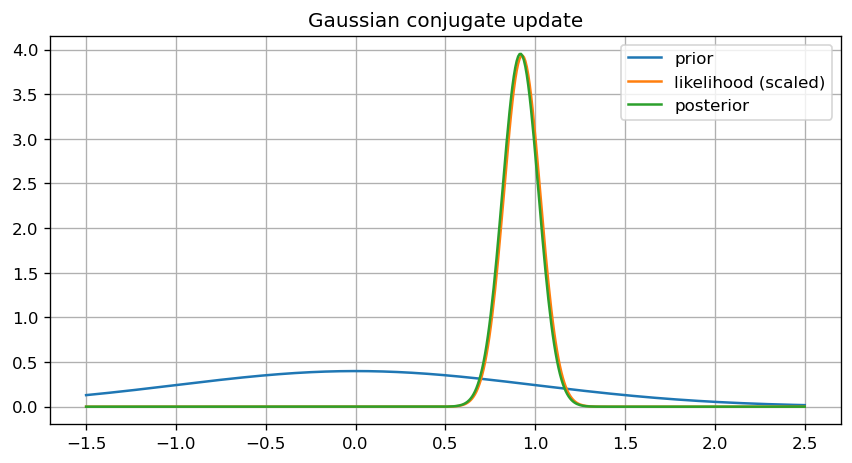

In [2]:
def posterior(mu0, s0):
    prec = 1/s0**2 + n/sigma**2
    mn = (mu0/s0**2 + y.sum()/sigma**2) / prec
    sn = np.sqrt(1/prec)
    return mn, sn

grid = np.linspace(-1.5, 2.5, 500)
mu0, s0 = 0.0, 1.0
mn, sn = posterior(mu0, s0)
prior = np.exp(-0.5*((grid-mu0)/s0)**2)/(np.sqrt(2*np.pi)*s0)
post = np.exp(-0.5*((grid-mn)/sn)**2)/(np.sqrt(2*np.pi)*sn)
like = np.exp(-0.5*n*((grid-y.mean())/sigma)**2)/(np.sqrt(2*np.pi)*sigma/np.sqrt(n))
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(grid, prior, label='prior')
ax.plot(grid, like, label='likelihood (scaled)')
ax.plot(grid, post, label='posterior')
ax.legend(); ax.set_title('Gaussian conjugate update')
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()


## Interactive: prior mean/std sliders
